In [1]:
import pandas as pd

df = pd.read_csv('/Users/gggyyu/Final_project/outputs/iM뱅크데이터_거시경제지표포함.csv')

In [2]:
df.columns

Index(['기준년월', '법인ID', '업종_대분류', '업종_중분류', '사업장_시도', '사업장_시군구', '법인_고객등급',
       '전담고객여부', '요구불예금잔액', '거치식예금잔액', '적립식예금잔액', '수익증권잔액', '신탁잔액', '퇴직연금잔액',
       '여신한도금액', '여신_운전자금대출잔액', '운전_할인어음잔액', '운전_당좌대출잔액', '운전_일반자금대출잔액',
       '운전_무역금융잔액', '운전_주택자금대출잔액', '운전_기업구매자금대출잔액', '운전_외상매출채권담보대출잔액',
       '운전_기타운전자금대출잔액', '여신_시설자금대출잔액', '시설_일반자금대출잔액', '시설_에너지절약시설대출잔액',
       '시설_주택자금대출잔액', '시설_기타시설자금대출잔액', '외환_수출실적금액', '외환_수입실적금액', '신용카드사용금액',
       '체크카드사용금액', '창구거래금액', '인터넷뱅킹거래금액', '스마트뱅킹거래금액', '폰뱅킹거래금액', 'ATM거래금액',
       '자동이체금액', '요구불입금금액', '요구불출금금액', '요구불예금좌수', '거치식예금좌수', '적립식예금좌수',
       '수익증권좌수', '신탁좌수', '퇴직연금좌수', '여신_운전자금대출좌수', '운전_할인어음좌수', '운전_당좌대출좌수',
       '운전_일반자금대출좌수', '운전_무역금융좌수', '운전_주택자금대출좌수', '운전_기업구매자금대출좌수',
       '운전_외상매출채권담보대출좌수', '운전_기타운전자금대출좌수', '여신_시설자금대출좌수', '시설_일반자금대출좌수',
       '시설_에너지절약시설대출좌수', '시설_주택자금대출좌수', '시설_기타시설자금대출좌수', '신용카드개수',
       '외환_수출실적거래건수', '외환_수입실적거래건수', '창구거래건수', '인터넷뱅킹거래건수', '스마트뱅킹거래건수',
       '폰뱅킹거래건수', 'ATM거래건수', '자동이체거래건수', '한국은행 기준

## 8. 법인별 FTP 기반 수익성 지표

이 절에서는 법인별 월별 대출·저축성수신·요구불예금 잔액에 상품별 경제적 마진을 곱해 은행 관점의 경제적 기여가치를 계산한다.

\[
V^{\mathrm{FTP}}_{i,m}
=
\left[
L_{i,m}(r^L_m-\mathrm{FTP}_m)
+D^S_{i,m}(\mathrm{FTP}_m-r^S_m)
+D^R_{i,m}(\mathrm{FTP}_m-r^R)
\right]
\times\frac{\mathrm{days}_m}{365}
\]

- `L`: 운전자금대출잔액 + 시설자금대출잔액
- `D^S`: 거치식예금잔액 + 적립식예금잔액
- `D^R`: 요구불예금잔액
- `r^L`, `r^S`: iM뱅크 월별 기업대출금리·저축성수신금리
- `r^R`: 요구불예금금리 0.01% (`0.0001`)
- `FTP`: iM뱅크 재무제표의 `원가성자금계` 공시 이자율을 단독 분기율로 환산한 대용치

> 중요: 공시된 반기·3분기·연간 이자율은 누적(YTD) 값이다. 평균잔액과 누적일수를 이용해 누적 이자비용을 복원하고 전기 누적액을 차감해 단독 분기율을 계산한다. 공시율이 소수 둘째 자리로 반올림되어 있으므로 단독 분기율은 추정치다. 잔액 단위가 백만원이면 산출된 기여가치도 백만원이다.


In [3]:
from pathlib import Path
import calendar
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')

try:
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['axes.unicode_minus'] = False
except Exception:
    pass

DATA_CSV = Path('/Users/gggyyu/Final_project/outputs/iM뱅크데이터_거시경제지표포함.csv')
RATE_CSV = Path('/Users/gggyyu/Final_project/outputs/예대금리차2023~2025_순.csv')

# 잔액이 월말잔액이라는 전제. 이미 월평균잔액이면 False로 바꾼다.
BALANCE_IS_MONTH_END = True
DEMAND_DEPOSIT_RATE = 0.0001  # 연 0.01%

print('설정 완료')
print(f'- 월말잔액 평균화 적용: {BALANCE_IS_MONTH_END}')
print(f'- 요구불예금금리: {DEMAND_DEPOSIT_RATE:.4%}')

설정 완료
- 월말잔액 평균화 적용: True
- 요구불예금금리: 0.0100%


### 8.1 재무제표 원가성자금 공시값

출처는 각 보고서의 `II. 사업의 내용 → 부문별 자금조달 운용 내용 → 은행계정(별도기준) → 자금조달실적 → 원가성자금계`이다.

- 2024년 1분기보고서 PDF 24쪽
- 2024년 반기보고서 PDF 24쪽
- 2024년 3분기보고서 PDF 23쪽
- 2024년 사업보고서 PDF 24쪽
- 2025년 1분기보고서 PDF 14쪽
- 2025년 반기보고서 PDF 23쪽
- 2025년 3분기보고서 PDF 17쪽

2023년은 제공된 보고서에서 연간값만 확인되므로 네 분기에 동일 적용한다. 2025년 4분기 보고서가 제공되지 않아 4분기는 2025년 3분기 단독 환산율을 이월하되 `FTP_근거구분`에 명시한다.


In [4]:
# 단위: 평균잔액 백만원, 이자율 %, 일수 누적
ftp_disclosures = pd.DataFrame([
    {'공시구간': '2023FY',     '연도': 2023, '누적분기': 4, '누적일수': 365, '원가성자금_평균잔액_백만원': 62_065_904, '공시_YTD이자율_pct': 2.72,
     '출처': '2024 사업보고서(2025.03.18), PDF 24쪽의 제67기'},
    {'공시구간': '2024Q1YTD',  '연도': 2024, '누적분기': 1, '누적일수': 91,  '원가성자금_평균잔액_백만원': 64_882_732, '공시_YTD이자율_pct': 2.80,
     '출처': '2024 1분기보고서(2024.05.14), PDF 24쪽'},
    {'공시구간': '2024H1YTD',  '연도': 2024, '누적분기': 2, '누적일수': 182, '원가성자금_평균잔액_백만원': 65_776_290, '공시_YTD이자율_pct': 2.76,
     '출처': '2024 반기보고서(2024.08.13), PDF 24쪽'},
    {'공시구간': '2024Q3YTD',  '연도': 2024, '누적분기': 3, '누적일수': 274, '원가성자금_평균잔액_백만원': 66_319_829, '공시_YTD이자율_pct': 2.74,
     '출처': '2024 3분기보고서(2024.11.14), PDF 23쪽'},
    {'공시구간': '2024FY',     '연도': 2024, '누적분기': 4, '누적일수': 366, '원가성자금_평균잔액_백만원': 66_995_977, '공시_YTD이자율_pct': 2.72,
     '출처': '2024 사업보고서(2025.03.18), PDF 24쪽'},
    {'공시구간': '2025Q1YTD',  '연도': 2025, '누적분기': 1, '누적일수': 90,  '원가성자금_평균잔액_백만원': 68_155_624, '공시_YTD이자율_pct': 2.51,
     '출처': '2025 1분기보고서(2025.05.15), PDF 14쪽'},
    {'공시구간': '2025H1YTD',  '연도': 2025, '누적분기': 2, '누적일수': 181, '원가성자금_평균잔액_백만원': 68_210_821, '공시_YTD이자율_pct': 2.42,
     '출처': '2025 반기보고서(2025.08.14), PDF 23쪽'},
    {'공시구간': '2025Q3YTD',  '연도': 2025, '누적분기': 3, '누적일수': 273, '원가성자금_평균잔액_백만원': 68_422_207, '공시_YTD이자율_pct': 2.33,
     '출처': '2025 3분기보고서(2025.11.14), PDF 17쪽'},
])

ftp_disclosures['공시_YTD이자율'] = ftp_disclosures['공시_YTD이자율_pct'] / 100
ftp_disclosures['누적_이자비용지수'] = (
    ftp_disclosures['원가성자금_평균잔액_백만원']
    * ftp_disclosures['공시_YTD이자율']
    * ftp_disclosures['누적일수']
)
ftp_disclosures['누적_잔액일수'] = (
    ftp_disclosures['원가성자금_평균잔액_백만원']
    * ftp_disclosures['누적일수']
)

display(ftp_disclosures[['공시구간', '원가성자금_평균잔액_백만원', '공시_YTD이자율_pct', '누적일수', '출처']])

,공시구간,원가성자금_평균잔액_백만원,공시_YTD이자율_pct,누적일수,출처
0,2023FY,62065904,2.720000,365,"2024 사업보고서(2025.03.18), PDF 24쪽의 제67기"
1,2024Q1YTD,64882732,2.800000,91,"2024 1분기보고서(2024.05.14), PDF 24쪽"
2,2024H1YTD,65776290,2.760000,182,"2024 반기보고서(2024.08.13), PDF 24쪽"
3,2024Q3YTD,66319829,2.740000,274,"2024 3분기보고서(2024.11.14), PDF 23쪽"
4,2024FY,66995977,2.720000,366,"2024 사업보고서(2025.03.18), PDF 24쪽"
5,2025Q1YTD,68155624,2.510000,90,"2025 1분기보고서(2025.05.15), PDF 14쪽"
6,2025H1YTD,68210821,2.420000,181,"2025 반기보고서(2025.08.14), PDF 23쪽"
7,2025Q3YTD,68422207,2.330000,273,"2025 3분기보고서(2025.11.14), PDF 17쪽"


In [5]:
# 누적 공시값에서 단독 분기 원가성자금 이자율 환산
standalone_rows = []
recon_rows = []

for year in [2024, 2025]:
    ytd = ftp_disclosures.loc[ftp_disclosures['연도'].eq(year)].sort_values('누적분기')
    prev_interest_index = 0.0
    prev_exposure = 0.0
    cumulative_interest_index = 0.0
    cumulative_exposure = 0.0

    for row in ytd.itertuples(index=False):
        q = int(row.누적분기)
        cumulative_interest_index = float(row.누적_이자비용지수)
        cumulative_exposure = float(row.누적_잔액일수)
        quarter_interest_index = cumulative_interest_index - prev_interest_index
        quarter_exposure = cumulative_exposure - prev_exposure
        standalone_rate = quarter_interest_index / quarter_exposure

        standalone_rows.append({
            '분기': pd.Period(f'{year}Q{q}', freq='Q'),
            'FTP_원가성자금': standalone_rate,
            'FTP_원가성자금_pct': standalone_rate * 100,
            '분기_잔액일수': quarter_exposure,
            '분기_이자비용지수': quarter_interest_index,
            'FTP_근거구분': '공시 누적값에서 단독분기 환산',
            'FTP_출처': row.출처,
        })

        reconstructed_ytd = (
            sum(x['분기_이자비용지수'] for x in standalone_rows if x['분기'].year == year)
            / sum(x['분기_잔액일수'] for x in standalone_rows if x['분기'].year == year)
        )
        recon_rows.append({
            '공시구간': row.공시구간,
            '공시_YTD이자율_pct': row.공시_YTD이자율_pct,
            '단독분기_재결합_YTD_pct': reconstructed_ytd * 100,
            '차이_bp': (reconstructed_ytd - row.공시_YTD이자율) * 10_000,
        })

        prev_interest_index = cumulative_interest_index
        prev_exposure = cumulative_exposure

ftp_quarter = pd.DataFrame(standalone_rows)

# 2023년은 제공 보고서에 연간값만 있어 분기별 동일 적용
rate_2023 = float(ftp_disclosures.loc[ftp_disclosures['공시구간'].eq('2023FY'), '공시_YTD이자율'].iloc[0])
rows_2023 = pd.DataFrame({
    '분기': pd.period_range('2023Q1', '2023Q4', freq='Q'),
    'FTP_원가성자금': rate_2023,
    'FTP_원가성자금_pct': rate_2023 * 100,
    '분기_잔액일수': np.nan,
    '분기_이자비용지수': np.nan,
    'FTP_근거구분': '2023 연간 공시율 동일 적용',
    'FTP_출처': '2024 사업보고서(2025.03.18), PDF 24쪽의 제67기',
})

# 2025Q4는 제공된 재무제표에 공시가 없어 최신 단독분기율을 이월
q3_2025 = ftp_quarter.loc[ftp_quarter['분기'].eq(pd.Period('2025Q3', freq='Q'))].iloc[0]
row_2025q4 = pd.DataFrame([{
    '분기': pd.Period('2025Q4', freq='Q'),
    'FTP_원가성자금': q3_2025['FTP_원가성자금'],
    'FTP_원가성자금_pct': q3_2025['FTP_원가성자금_pct'],
    '분기_잔액일수': np.nan,
    '분기_이자비용지수': np.nan,
    'FTP_근거구분': '직전 단독분기율 이월(2025Q4 보고서 미제공)',
    'FTP_출처': '2025 3분기보고서(2025.11.14), PDF 17쪽',
}])

ftp_quarter = (
    pd.concat([rows_2023, ftp_quarter, row_2025q4], ignore_index=True)
    .sort_values('분기')
    .reset_index(drop=True)
)
ftp_reconciliation = pd.DataFrame(recon_rows)

display(ftp_quarter[['분기', 'FTP_원가성자금_pct', 'FTP_근거구분', 'FTP_출처']])
print('\n누적 공시율 재결합 정합성')
display(ftp_reconciliation)

,분기,FTP_원가성자금_pct,FTP_근거구분,FTP_출처
0,2023Q1,2.720000,2023 연간 공시율 동일 적용,"2024 사업보고서(2025.03.18), PDF 24쪽의 제67기"
1,2023Q2,2.720000,2023 연간 공시율 동일 적용,"2024 사업보고서(2025.03.18), PDF 24쪽의 제67기"
2,2023Q3,2.720000,2023 연간 공시율 동일 적용,"2024 사업보고서(2025.03.18), PDF 24쪽의 제67기"
3,2023Q4,2.720000,2023 연간 공시율 동일 적용,"2024 사업보고서(2025.03.18), PDF 24쪽의 제67기"
4,2024Q1,2.800000,공시 누적값에서 단독분기 환산,"2024 1분기보고서(2024.05.14), PDF 24쪽"
5,2024Q2,2.721072,공시 누적값에서 단독분기 환산,"2024 반기보고서(2024.08.13), PDF 24쪽"
6,2024Q3,2.701385,공시 누적값에서 단독분기 환산,"2024 3분기보고서(2024.11.14), PDF 23쪽"
7,2024Q4,2.662757,공시 누적값에서 단독분기 환산,"2024 사업보고서(2025.03.18), PDF 24쪽"
8,2025Q1,2.510000,공시 누적값에서 단독분기 환산,"2025 1분기보고서(2025.05.15), PDF 14쪽"
9,2025Q2,2.331132,공시 누적값에서 단독분기 환산,"2025 반기보고서(2025.08.14), PDF 23쪽"



누적 공시율 재결합 정합성


,공시구간,공시_YTD이자율_pct,단독분기_재결합_YTD_pct,차이_bp
0,2024Q1YTD,2.800000,2.800000,0.000000
1,2024H1YTD,2.760000,2.760000,0.000000
2,2024Q3YTD,2.740000,2.740000,0.000000
3,2024FY,2.720000,2.720000,-0.000000
4,2025Q1YTD,2.510000,2.510000,0.000000
5,2025H1YTD,2.420000,2.420000,-0.000000
6,2025Q3YTD,2.330000,2.330000,0.000000


### 8.2 월별 기업대출금리·저축성수신금리 정제

금리 CSV는 가로형이므로 `은행·구분 × 월` 구조를 `월 × 금리종류`로 변환한다. 금리 값은 CSV에서 % 단위이므로 계산 전에 100으로 나눠 소수로 변환한다.


In [6]:
rate_raw = pd.read_csv(RATE_CSV)
rate_raw['은행'] = rate_raw['은행'].ffill()

id_cols = ['은행', '구분']
month_cols = [c for c in rate_raw.columns if c not in id_cols]
rate_long = rate_raw.melt(
    id_vars=id_cols,
    value_vars=month_cols,
    var_name='월표기',
    value_name='금리_pct'
)
rate_long['기준월'] = pd.to_datetime(
    rate_long['월표기'].str.extract(r'(\d{4}년\d{2}월)', expand=False),
    format='%Y년%m월',
    errors='coerce'
)
rate_long['금리_pct'] = pd.to_numeric(rate_long['금리_pct'], errors='coerce')

target_rates = rate_long.loc[
    rate_long['은행'].str.contains('iM뱅크', na=False)
    & rate_long['구분'].isin(['기업대출금리', '저축성수신금리'])
].copy()

rate_month = (
    target_rates.pivot(index='기준월', columns='구분', values='금리_pct')
    .reset_index()
    .rename_axis(None, axis=1)
    .rename(columns={
        '기업대출금리': '기업대출금리_pct',
        '저축성수신금리': '저축성수신금리_pct'
    })
    .sort_values('기준월')
)
rate_month['기업대출금리'] = rate_month['기업대출금리_pct'] / 100
rate_month['저축성수신금리'] = rate_month['저축성수신금리_pct'] / 100
rate_month['분기'] = rate_month['기준월'].dt.to_period('Q')
rate_month = rate_month.merge(
    ftp_quarter[['분기', 'FTP_원가성자금', 'FTP_원가성자금_pct', 'FTP_근거구분', 'FTP_출처']],
    on='분기',
    how='left',
    validate='many_to_one'
)

display(rate_month.head(12))
display(rate_month.tail(6))

,기준월,기업대출금리_pct,저축성수신금리_pct,기업대출금리,저축성수신금리,분기,FTP_원가성자금,FTP_원가성자금_pct,FTP_근거구분,FTP_출처
0,2023-01-01,5.750000,3.990000,0.057500,0.039900,2023Q1,0.027200,2.720000,2023 연간 공시율 동일 적용,"2024 사업보고서(2025.03.18), PDF 24쪽의 제67기"
1,2023-02-01,5.690000,3.700000,0.056900,0.037000,2023Q1,0.027200,2.720000,2023 연간 공시율 동일 적용,"2024 사업보고서(2025.03.18), PDF 24쪽의 제67기"
2,2023-03-01,5.480000,3.460000,0.054800,0.034600,2023Q1,0.027200,2.720000,2023 연간 공시율 동일 적용,"2024 사업보고서(2025.03.18), PDF 24쪽의 제67기"
3,2023-04-01,5.400000,3.320000,0.054000,0.033200,2023Q2,0.027200,2.720000,2023 연간 공시율 동일 적용,"2024 사업보고서(2025.03.18), PDF 24쪽의 제67기"
4,2023-05-01,5.510000,3.350000,0.055100,0.033500,2023Q2,0.027200,2.720000,2023 연간 공시율 동일 적용,"2024 사업보고서(2025.03.18), PDF 24쪽의 제67기"
5,2023-06-01,5.600000,3.300000,0.056000,0.033000,2023Q2,0.027200,2.720000,2023 연간 공시율 동일 적용,"2024 사업보고서(2025.03.18), PDF 24쪽의 제67기"
6,2023-07-01,5.480000,3.540000,0.054800,0.035400,2023Q3,0.027200,2.720000,2023 연간 공시율 동일 적용,"2024 사업보고서(2025.03.18), PDF 24쪽의 제67기"
7,2023-08-01,5.500000,3.590000,0.055000,0.035900,2023Q3,0.027200,2.720000,2023 연간 공시율 동일 적용,"2024 사업보고서(2025.03.18), PDF 24쪽의 제67기"
8,2023-09-01,5.670000,3.630000,0.056700,0.036300,2023Q3,0.027200,2.720000,2023 연간 공시율 동일 적용,"2024 사업보고서(2025.03.18), PDF 24쪽의 제67기"
9,2023-10-01,5.740000,3.940000,0.057400,0.039400,2023Q4,0.027200,2.720000,2023 연간 공시율 동일 적용,"2024 사업보고서(2025.03.18), PDF 24쪽의 제67기"


,기준월,기업대출금리_pct,저축성수신금리_pct,기업대출금리,저축성수신금리,분기,FTP_원가성자금,FTP_원가성자금_pct,FTP_근거구분,FTP_출처
30,2025-07-01,4.110000,2.410000,0.041100,0.024100,2025Q3,0.021545,2.154548,공시 누적값에서 단독분기 환산,"2025 3분기보고서(2025.11.14), PDF 17쪽"
31,2025-08-01,4.340000,2.450000,0.043400,0.024500,2025Q3,0.021545,2.154548,공시 누적값에서 단독분기 환산,"2025 3분기보고서(2025.11.14), PDF 17쪽"
32,2025-09-01,4.320000,2.430000,0.043200,0.024300,2025Q3,0.021545,2.154548,공시 누적값에서 단독분기 환산,"2025 3분기보고서(2025.11.14), PDF 17쪽"
33,2025-10-01,4.260000,2.480000,0.042600,0.024800,2025Q4,0.021545,2.154548,직전 단독분기율 이월(2025Q4 보고서 미제공),"2025 3분기보고서(2025.11.14), PDF 17쪽"
34,2025-11-01,4.310000,2.640000,0.043100,0.026400,2025Q4,0.021545,2.154548,직전 단독분기율 이월(2025Q4 보고서 미제공),"2025 3분기보고서(2025.11.14), PDF 17쪽"
35,2025-12-01,4.280000,2.740000,0.042800,0.027400,2025Q4,0.021545,2.154548,직전 단독분기율 이월(2025Q4 보고서 미제공),"2025 3분기보고서(2025.11.14), PDF 17쪽"


### 8.3 법인별 월평균잔액 구성

원본 잔액이 월말잔액이면 `(전월말 + 당월말) / 2`로 월평균잔액을 근사한다. 첫 관측월은 전월말이 없으므로 당월말잔액을 사용한다. 원본이 이미 월평균잔액이면 설정 셀의 `BALANCE_IS_MONTH_END=False`로 바꾼다.

대출총액과 세부 대출잔액을 동시에 합산하지 않고 상위 집계열인 운전자금·시설자금 잔액만 사용해 중복을 방지한다.


In [7]:
required_cols = [
    '기준년월', '법인ID',
    '요구불예금잔액', '거치식예금잔액', '적립식예금잔액',
    '여신_운전자금대출잔액', '여신_시설자금대출잔액'
]
missing_required = sorted(set(required_cols) - set(df.columns))
if missing_required:
    raise KeyError(f'필수 컬럼 누락: {missing_required}')

df_profit = df.copy()
df_profit['기준월'] = pd.to_datetime(
    df_profit['기준년월'].astype(str), format='%Y%m', errors='raise'
)
df_profit = df_profit.sort_values(['법인ID', '기준월']).reset_index(drop=True)

df_profit['대출잔액_월말'] = (
    df_profit['여신_운전자금대출잔액']
    + df_profit['여신_시설자금대출잔액']
)
df_profit['저축성수신잔액_월말'] = (
    df_profit['거치식예금잔액']
    + df_profit['적립식예금잔액']
)
df_profit['요구불예금잔액_월말'] = df_profit['요구불예금잔액']

balance_pairs = [
    ('대출잔액_월말', '대출잔액_월평균'),
    ('저축성수신잔액_월말', '저축성수신잔액_월평균'),
    ('요구불예금잔액_월말', '요구불예금잔액_월평균'),
]

for month_end_col, monthly_avg_col in balance_pairs:
    if BALANCE_IS_MONTH_END:
        previous = df_profit.groupby('법인ID', sort=False)[month_end_col].shift(1)
        df_profit[monthly_avg_col] = np.where(
            previous.notna(),
            (previous + df_profit[month_end_col]) / 2,
            df_profit[month_end_col]
        )
    else:
        df_profit[monthly_avg_col] = df_profit[month_end_col]

df_profit['월평균잔액_근사구분'] = np.where(
    df_profit.groupby('법인ID').cumcount().eq(0) & BALANCE_IS_MONTH_END,
    '첫월 당월말 대체',
    '전월말·당월말 평균' if BALANCE_IS_MONTH_END else '원본 월평균잔액 사용'
)

display(df_profit[[
    '기준월', '법인ID',
    '대출잔액_월말', '대출잔액_월평균',
    '저축성수신잔액_월말', '저축성수신잔액_월평균',
    '요구불예금잔액_월말', '요구불예금잔액_월평균',
    '월평균잔액_근사구분'
]].head())

,기준월,법인ID,대출잔액_월말,대출잔액_월평균,저축성수신잔액_월말,저축성수신잔액_월평균,요구불예금잔액_월말,요구불예금잔액_월평균,월평균잔액_근사구분
0,2023-01-01,000fd5948a0ec34ce399733e5f9ce20477d0037286c99f...,"2,450.000000","2,450.000000",0.000000,0.000000,44.000000,44.000000,첫월 당월말 대체
1,2023-02-01,000fd5948a0ec34ce399733e5f9ce20477d0037286c99f...,"2,450.000000","2,450.000000",0.000000,0.000000,56.000000,50.000000,전월말·당월말 평균
2,2023-03-01,000fd5948a0ec34ce399733e5f9ce20477d0037286c99f...,"2,450.000000","2,450.000000",0.000000,0.000000,22.000000,39.000000,전월말·당월말 평균
3,2023-04-01,000fd5948a0ec34ce399733e5f9ce20477d0037286c99f...,"2,450.000000","2,450.000000",0.000000,0.000000,24.000000,23.000000,전월말·당월말 평균
4,2023-05-01,000fd5948a0ec34ce399733e5f9ce20477d0037286c99f...,"2,450.000000","2,450.000000",0.000000,0.000000,30.000000,27.000000,전월말·당월말 평균


### 8.4 월별 FTP 기반 경제적 기여가치 계산

마진이 음수인 상품은 그대로 음의 기여로 남긴다. 그래야 수익성 손실 고객을 식별할 수 있다. 방어 우선순위에 연결할 때만 `max(V, 0)` 형태의 `V_FTP_12M_방어가치`를 사용한다.


In [8]:
df_profit = df_profit.merge(
    rate_month[[
        '기준월', '분기',
        '기업대출금리', '기업대출금리_pct',
        '저축성수신금리', '저축성수신금리_pct',
        'FTP_원가성자금', 'FTP_원가성자금_pct',
        'FTP_근거구분', 'FTP_출처'
    ]],
    on='기준월',
    how='left',
    validate='many_to_one'
)

df_profit['요구불예금금리'] = DEMAND_DEPOSIT_RATE
df_profit['월일수'] = df_profit['기준월'].dt.days_in_month
df_profit['연환산계수'] = df_profit['월일수'] / 365

df_profit['대출_FTP마진'] = (
    df_profit['기업대출금리'] - df_profit['FTP_원가성자금']
)
df_profit['저축성수신_FTP마진'] = (
    df_profit['FTP_원가성자금'] - df_profit['저축성수신금리']
)
df_profit['요구불예금_FTP마진'] = (
    df_profit['FTP_원가성자금'] - df_profit['요구불예금금리']
)

df_profit['V_FTP_월_대출기여'] = (
    df_profit['대출잔액_월평균']
    * df_profit['대출_FTP마진']
    * df_profit['연환산계수']
)
df_profit['V_FTP_월_저축성수신기여'] = (
    df_profit['저축성수신잔액_월평균']
    * df_profit['저축성수신_FTP마진']
    * df_profit['연환산계수']
)
df_profit['V_FTP_월_요구불예금기여'] = (
    df_profit['요구불예금잔액_월평균']
    * df_profit['요구불예금_FTP마진']
    * df_profit['연환산계수']
)

component_cols = [
    'V_FTP_월_대출기여',
    'V_FTP_월_저축성수신기여',
    'V_FTP_월_요구불예금기여'
]
df_profit['V_FTP_월'] = df_profit[component_cols].sum(axis=1)

# 최근 12개월 완전창만 사용. 첫 11개월은 NaN으로 남긴다.
df_profit['V_FTP_12M'] = (
    df_profit.groupby('법인ID', sort=False)['V_FTP_월']
    .transform(lambda s: s.rolling(window=12, min_periods=12).sum())
)
df_profit['V_FTP_12M_방어가치'] = df_profit['V_FTP_12M'].clip(lower=0)
df_profit['V_FTP_12M_순위'] = (
    df_profit.groupby('기준월')['V_FTP_12M_방어가치']
    .rank(method='min', ascending=False)
)
df_profit['V_FTP_12M_상대백분위'] = (
    df_profit.groupby('기준월')['V_FTP_12M_방어가치']
    .rank(method='average', pct=True)
)

profit_cols = [
    '기준월', '법인ID', '분기',
    '기업대출금리_pct', '저축성수신금리_pct', 'FTP_원가성자금_pct', 'FTP_근거구분',
    '대출잔액_월평균', '저축성수신잔액_월평균', '요구불예금잔액_월평균',
    '대출_FTP마진', '저축성수신_FTP마진', '요구불예금_FTP마진',
    'V_FTP_월_대출기여', 'V_FTP_월_저축성수신기여', 'V_FTP_월_요구불예금기여',
    'V_FTP_월', 'V_FTP_12M', 'V_FTP_12M_방어가치', 'V_FTP_12M_순위', 'V_FTP_12M_상대백분위'
]

display(df_profit[profit_cols].tail())

,기준월,법인ID,분기,기업대출금리_pct,저축성수신금리_pct,FTP_원가성자금_pct,FTP_근거구분,대출잔액_월평균,저축성수신잔액_월평균,요구불예금잔액_월평균,대출_FTP마진,저축성수신_FTP마진,요구불예금_FTP마진,V_FTP_월_대출기여,V_FTP_월_저축성수신기여,V_FTP_월_요구불예금기여,V_FTP_월,V_FTP_12M,V_FTP_12M_방어가치,V_FTP_12M_순위,V_FTP_12M_상대백분위
121387,2025-08-01,ffed592946900dee9903846d0dd9b19d019eb81bdd2deb...,2025Q3,4.340000,2.450000,2.154548,공시 누적값에서 단독분기 환산,"1,600.000000",0.000000,5.700000,0.021855,-0.002955,0.021445,2.969819,-0.000000,0.010382,2.980201,34.297101,34.297101,797.000000,0.763938
121388,2025-09-01,ffed592946900dee9903846d0dd9b19d019eb81bdd2deb...,2025Q3,4.320000,2.430000,2.154548,공시 누적값에서 단독분기 환산,"1,600.000000",0.000000,5.800000,0.021655,-0.002755,0.021445,2.847717,-0.000000,0.010223,2.857941,34.077601,34.077601,797.000000,0.763938
121389,2025-10-01,ffed592946900dee9903846d0dd9b19d019eb81bdd2deb...,2025Q4,4.260000,2.480000,2.154548,직전 단독분기율 이월(2025Q4 보고서 미제공),"1,600.000000",0.000000,7.100000,0.021055,-0.003255,0.021445,2.861107,-0.000000,0.012932,2.874039,33.740670,33.740670,797.000000,0.763938
121390,2025-11-01,ffed592946900dee9903846d0dd9b19d019eb81bdd2deb...,2025Q4,4.310000,2.640000,2.154548,직전 단독분기율 이월(2025Q4 보고서 미제공),"1,600.000000",0.000000,7.200000,0.021555,-0.004855,0.021445,2.834567,-0.000000,0.012691,2.847258,33.622946,33.622946,798.000000,0.763642
121391,2025-12-01,ffed592946900dee9903846d0dd9b19d019eb81bdd2deb...,2025Q4,4.280000,2.740000,2.154548,직전 단독분기율 이월(2025Q4 보고서 미제공),"1,600.000000",0.000000,6.450000,0.021255,-0.005855,0.021445,2.888285,-0.000000,0.011748,2.900033,33.446477,33.446477,794.000000,0.764828


### 8.5 정합성 검사

아래 검사는 데이터 키, 36개월 완전관측, 금리 매핑, 단위 범위, 잔액 부호, 월평균 계산, 구성요소 합계, 12개월 롤링 개수 및 누적 공시율 재결합을 확인한다. `PASS`가 아닌 항목이 있으면 다음 단계로 진행하기 전에 원인을 확인한다.


In [9]:
checks = []

def add_check(name, actual, expected, passed, note=''):
    checks.append({
        '검사항목': name,
        '실제값': actual,
        '기대값': expected,
        '상태': 'PASS' if bool(passed) else 'FAIL',
        '비고': note,
    })

firm_count = int(df_profit['법인ID'].nunique())
month_count = int(df_profit['기준월'].nunique())
row_count = len(df_profit)

add_check('법인×월 키 중복', int(df_profit.duplicated(['법인ID', '기준월']).sum()), 0,
          df_profit.duplicated(['법인ID', '기준월']).sum() == 0)
add_check('전체 법인 수', firm_count, 3372, firm_count == 3372)
add_check('월 수', month_count, 36, month_count == 36)
add_check('전체 행 수', row_count, firm_count * month_count, row_count == firm_count * month_count)

months_per_firm = df_profit.groupby('법인ID')['기준월'].nunique()
add_check('법인별 36개월 완전관측', f'{months_per_firm.min()}~{months_per_firm.max()}', '36~36',
          months_per_firm.min() == 36 and months_per_firm.max() == 36)

rate_cols = ['기업대출금리', '저축성수신금리', 'FTP_원가성자금']
missing_rates = int(df_profit[rate_cols].isna().sum().sum())
add_check('월별 금리 매핑 누락', missing_rates, 0, missing_rates == 0)

rate_plausible = bool(
    df_profit['기업대출금리'].between(0, 0.20).all()
    and df_profit['저축성수신금리'].between(0, 0.20).all()
    and df_profit['FTP_원가성자금'].between(0, 0.10).all()
)
add_check('금리 소수 변환·범위', rate_plausible, True, rate_plausible,
          '대출·수신 0~20%, FTP 0~10%')

balance_cols = [
    '대출잔액_월말', '저축성수신잔액_월말', '요구불예금잔액_월말',
    '대출잔액_월평균', '저축성수신잔액_월평균', '요구불예금잔액_월평균'
]
missing_balances = int(df_profit[balance_cols].isna().sum().sum())
negative_balances = int((df_profit[balance_cols] < 0).sum().sum())
add_check('잔액 결측', missing_balances, 0, missing_balances == 0)
add_check('잔액 음수', negative_balances, 0, negative_balances == 0)

if BALANCE_IS_MONTH_END:
    test_col = '대출잔액_월말'
    prev = df_profit.groupby('법인ID', sort=False)[test_col].shift(1)
    expected_avg = np.where(prev.notna(), (prev + df_profit[test_col]) / 2, df_profit[test_col])
    avg_diff = float(np.nanmax(np.abs(expected_avg - df_profit['대출잔액_월평균'])))
else:
    avg_diff = float(np.nanmax(np.abs(df_profit['대출잔액_월말'] - df_profit['대출잔액_월평균'])))
add_check('월평균잔액 계산', avg_diff, 0.0, np.isclose(avg_diff, 0.0))

component_diff = float(np.nanmax(np.abs(df_profit['V_FTP_월'] - df_profit[component_cols].sum(axis=1))))
add_check('월 기여가치 구성요소 합계', component_diff, 0.0, np.isclose(component_diff, 0.0, atol=1e-12))

finite_profit = bool(np.isfinite(df_profit[['V_FTP_월'] + component_cols].to_numpy()).all())
add_check('월 기여가치 유한값', finite_profit, True, finite_profit)

expected_12m_nonnull = firm_count * (month_count - 11)
actual_12m_nonnull = int(df_profit['V_FTP_12M'].notna().sum())
add_check('12개월 완전창 개수', actual_12m_nonnull, expected_12m_nonnull,
          actual_12m_nonnull == expected_12m_nonnull)

recon_max_bp = float(ftp_reconciliation['차이_bp'].abs().max())
add_check('누적 공시율 재결합 오차(bp)', recon_max_bp, '0에 근접', recon_max_bp < 1e-8,
          '공시 반올림값을 입력으로 사용한 산술 재결합')

proxy_q4_count = int(
    df_profit.loc[df_profit['FTP_근거구분'].str.contains('이월', na=False), '기준월'].nunique()
)
add_check('2025Q4 이월 proxy 월 수', proxy_q4_count, 3, proxy_q4_count == 3,
          '2025Q4 보고서 미제공으로 2025Q3 단독 환산율 이월')

qa_checks = pd.DataFrame(checks)
display(qa_checks)

if not qa_checks['상태'].eq('PASS').all():
    failed = qa_checks.loc[qa_checks['상태'].ne('PASS')]
    raise AssertionError(f'정합성 검사 실패:\n{failed.to_string(index=False)}')

print('MODEL STATUS: PASS')

,검사항목,실제값,기대값,상태,비고
0,법인×월 키 중복,0,0,PASS,
1,전체 법인 수,3372,3372,PASS,
2,월 수,36,36,PASS,
3,전체 행 수,121392,121392,PASS,
4,법인별 36개월 완전관측,36~36,36~36,PASS,
5,월별 금리 매핑 누락,0,0,PASS,
6,금리 소수 변환·범위,True,True,PASS,"대출·수신 0~20%, FTP 0~10%"
7,잔액 결측,0,0,PASS,
8,잔액 음수,0,0,PASS,
9,월평균잔액 계산,0.000000,0.000000,PASS,


MODEL STATUS: PASS


### 8.6 산출 결과 요약과 시각화

`df_profit`은 원본 데이터에 월별 금리·FTP·월평균잔액·상품별 기여가치·12개월 가치·월별 순위를 붙인 최종 법인×월 데이터프레임이다. `latest_profit`은 마지막 관측월의 법인별 결과다.


In [10]:
monthly_profit_summary = (
    df_profit.groupby('기준월', as_index=False)
    .agg(
        법인수=('법인ID', 'nunique'),
        대출기여=('V_FTP_월_대출기여', 'sum'),
        저축성수신기여=('V_FTP_월_저축성수신기여', 'sum'),
        요구불예금기여=('V_FTP_월_요구불예금기여', 'sum'),
        총기여=('V_FTP_월', 'sum'),
        FTP_pct=('FTP_원가성자금_pct', 'first'),
        기업대출금리_pct=('기업대출금리_pct', 'first'),
        저축성수신금리_pct=('저축성수신금리_pct', 'first'),
    )
)

latest_month = df_profit['기준월'].max()
latest_profit = (
    df_profit.loc[df_profit['기준월'].eq(latest_month), profit_cols]
    .sort_values(['V_FTP_12M_방어가치', 'V_FTP_12M'], ascending=False)
    .reset_index(drop=True)
)

print(f'최종 법인×월 데이터: {df_profit.shape[0]:,}행 × {df_profit.shape[1]:,}열')
print(f'마지막 관측월: {latest_month:%Y-%m}, 법인 수: {latest_profit["법인ID"].nunique():,}')
print(f'12M 가치 양수 법인: {(latest_profit["V_FTP_12M"] > 0).sum():,}')
print(f'12M 가치 0 이하 법인: {(latest_profit["V_FTP_12M"] <= 0).sum():,}')

display(monthly_profit_summary.tail(12))
display(latest_profit.head(20))

최종 법인×월 데이터: 121,392행 × 125열
마지막 관측월: 2025-12, 법인 수: 3,372
12M 가치 양수 법인: 3,355
12M 가치 0 이하 법인: 17


,기준월,법인수,대출기여,저축성수신기여,요구불예금기여,총기여,FTP_pct,기업대출금리_pct,저축성수신금리_pct
24,2025-01-01,3372,"10,249.720334",-183.829144,"1,377.210332","11,443.101521",2.510000,4.700000,2.960000
25,2025-02-01,3372,"8,859.226642",-155.477930,953.574290,"9,657.323002",2.510000,4.600000,2.940000
26,2025-03-01,3372,"9,582.776363",-112.566651,"1,001.561695","10,471.771406",2.510000,4.550000,2.790000
27,2025-04-01,3372,"9,610.740638",-137.906644,911.278808,"10,384.112802",2.331132,4.450000,2.680000
28,2025-05-01,3372,"9,131.886174",-114.783785,926.152969,"9,943.255358",2.331132,4.290000,2.600000
29,2025-06-01,3372,"8,681.741232",-80.883536,973.055067,"9,573.912762",2.331132,4.260000,2.520000
30,2025-07-01,3372,"9,042.358982",-112.965081,972.374887,"9,901.768788",2.154548,4.110000,2.410000
31,2025-08-01,3372,"10,077.072169",-131.087955,917.515863,"10,863.500077",2.154548,4.340000,2.450000
32,2025-09-01,3372,"9,690.599615",-121.138141,"1,063.747187","10,633.208662",2.154548,4.320000,2.430000
33,2025-10-01,3372,"9,736.666148",-150.168990,"1,086.199922","10,672.697081",2.154548,4.260000,2.480000


,기준월,법인ID,분기,기업대출금리_pct,저축성수신금리_pct,FTP_원가성자금_pct,FTP_근거구분,대출잔액_월평균,저축성수신잔액_월평균,요구불예금잔액_월평균,대출_FTP마진,저축성수신_FTP마진,요구불예금_FTP마진,V_FTP_월_대출기여,V_FTP_월_저축성수신기여,V_FTP_월_요구불예금기여,V_FTP_월,V_FTP_12M,V_FTP_12M_방어가치,V_FTP_12M_순위,V_FTP_12M_상대백분위
0,2025-12-01,4e7ad9901bab418169f38303bc4cac9e36e0f0d2dcac42...,2025Q4,4.280000,2.740000,2.154548,직전 단독분기율 이월(2025Q4 보고서 미제공),"167,500.000000",0.000000,305.000000,0.021255,-0.005855,0.021445,302.367351,-0.000000,0.555526,302.922877,"3,488.367328","3,488.367328",1.000000,1.000000
1,2025-12-01,16fd9d1d20d81b2d9e50883e9474451fb50488a75d505e...,2025Q4,4.280000,2.740000,2.154548,직전 단독분기율 이월(2025Q4 보고서 미제공),"110,000.000000",900.000000,"4,850.000000",0.021255,-0.005855,0.021445,198.569603,-0.447510,8.833776,206.955870,"2,534.333268","2,534.333268",2.000000,0.999703
2,2025-12-01,5c0b1540b4c430f010cdd9469ac4ad5df867be0e43b369...,2025Q4,4.280000,2.740000,2.154548,직전 단독분기율 이월(2025Q4 보고서 미제공),0.000000,0.000000,"32,700.000000",0.021255,-0.005855,0.021445,0.000000,-0.000000,59.559686,59.559686,"1,955.164789","1,955.164789",3.000000,0.999407
3,2025-12-01,3cc8053fe777755382210317a61e6f56a44e6ed2ebe0bc...,2025Q4,4.280000,2.740000,2.154548,직전 단독분기율 이월(2025Q4 보고서 미제공),"87,000.000000",0.000000,560.000000,0.021255,-0.005855,0.021445,157.050505,-0.000000,1.019982,158.070487,"1,819.696513","1,819.696513",4.000000,0.999110
4,2025-12-01,6d6e92da5783b5f5f310fec2ebb0e402312fae2d34c10b...,2025Q4,4.280000,2.740000,2.154548,직전 단독분기율 이월(2025Q4 보고서 미제공),"74,500.000000",0.000000,245.000000,0.021255,-0.005855,0.021445,134.485777,-0.000000,0.446242,134.932019,"1,580.297524","1,580.297524",5.000000,0.998814
5,2025-12-01,9ff081ed2101fb5064f3425d1f5606ce6bf64696c0b9ba...,2025Q4,4.280000,2.740000,2.154548,직전 단독분기율 이월(2025Q4 보고서 미제공),"64,500.000000",21.500000,"1,920.000000",0.021255,-0.005855,0.021445,116.433995,-0.010691,3.497082,119.920387,"1,330.367315","1,330.367315",6.000000,0.998517
6,2025-12-01,d7f765af410ab5750e69acb3226b2bd1e2a106d3b105c6...,2025Q4,4.280000,2.740000,2.154548,직전 단독분기율 이월(2025Q4 보고서 미제공),"64,700.000000",0.000000,450.000000,0.021255,-0.005855,0.021445,116.795030,-0.000000,0.819629,117.614659,"1,258.914463","1,258.914463",7.000000,0.998221
7,2025-12-01,ec4bfc4897569fd894291d08a78684905dcba46d0cc5ef...,2025Q4,4.280000,2.740000,2.154548,직전 단독분기율 이월(2025Q4 보고서 미제공),"44,150.000000",0.000000,"6,050.000000",0.021255,-0.005855,0.021445,79.698618,-0.000000,11.019453,90.718071,"1,012.964187","1,012.964187",8.000000,0.997924
8,2025-12-01,9ed6287e5e8f105f8c27fd1333a68a80fddda6ff9c065b...,2025Q4,4.280000,2.740000,2.154548,직전 단독분기율 이월(2025Q4 보고서 미제공),"51,500.000000",410.000000,195.000000,0.021255,-0.005855,0.021445,92.966678,-0.203866,0.355172,93.117985,992.915115,992.915115,9.000000,0.997628
9,2025-12-01,83cb9d69574990674667c49cdb23f41bbd35db1fe63679...,2025Q4,4.280000,2.740000,2.154548,직전 단독분기율 이월(2025Q4 보고서 미제공),"50,000.000000","4,200.000000",565.000000,0.021255,-0.005855,0.021445,90.258911,-2.088379,1.029089,89.199621,907.216483,907.216483,10.000000,0.997331


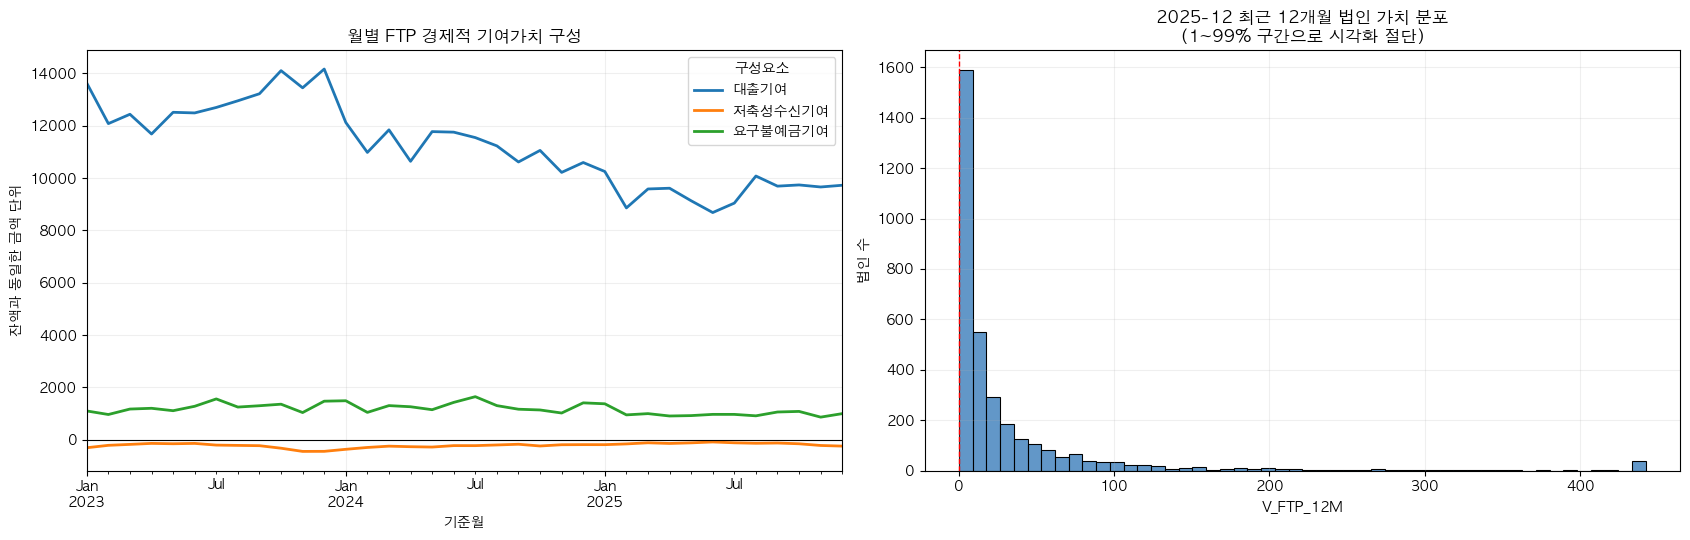

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5.5))

plot_df = monthly_profit_summary.set_index('기준월')[['대출기여', '저축성수신기여', '요구불예금기여']]
plot_df.plot(ax=axes[0], linewidth=2)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('월별 FTP 경제적 기여가치 구성')
axes[0].set_xlabel('기준월')
axes[0].set_ylabel('잔액과 동일한 금액 단위')
axes[0].legend(title='구성요소')
axes[0].grid(alpha=0.2)

latest_v = latest_profit['V_FTP_12M'].dropna()
low, high = latest_v.quantile([0.01, 0.99])
sns.histplot(latest_v.clip(low, high), bins=50, ax=axes[1], color='#2E75B6')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_title(f'{latest_month:%Y-%m} 최근 12개월 법인 가치 분포\n(1~99% 구간으로 시각화 절단)')
axes[1].set_xlabel('V_FTP_12M')
axes[1].set_ylabel('법인 수')
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

### 8.7 다음 단계 연결

모델의 급감·침묵 확률과 세그먼트 사슬계수가 준비되면 다음 두 열을 추가한다.

\[
P^{\mathrm{leave}}_{i,m}
=
\min\left(1,\;P^{\mathrm{silence}}_{i,m}	imes \mathrm{ChainFactor}_{s(i)}
ight)
\]

\[
\mathrm{DefensePriority}_{i,m}
=
P^{\mathrm{leave}}_{i,m}	imes\max(V^{12M}_{i,m},0)
\]

`V_FTP_12M` 원본은 음수를 유지하고, RM 정렬용으로는 `V_FTP_12M_방어가치`를 사용한다.


In [12]:
# 선택사항: 결과 저장. 기본값 False로 두어 의도치 않은 대용량 파일 생성을 막는다.
EXPORT_RESULT = False
OUTPUT_CSV = Path('/Users/changeun_1/Desktop/iM/5. final/법인월별_FTP수익성.csv')

if EXPORT_RESULT:
    export_cols = list(dict.fromkeys(list(df.columns) + profit_cols + [
        '대출잔액_월말', '저축성수신잔액_월말', '요구불예금잔액_월말',
        '월평균잔액_근사구분', '요구불예금금리', '월일수', 'FTP_출처'
    ]))
    df_profit[export_cols].to_csv(OUTPUT_CSV, index=False, encoding='utf-8-sig')
    print(f'저장 완료: {OUTPUT_CSV}')
else:
    print('EXPORT_RESULT=False: 결과는 df_profit과 latest_profit에 메모리로 보관되어 있습니다.')

EXPORT_RESULT=False: 결과는 df_profit과 latest_profit에 메모리로 보관되어 있습니다.
